# Autoregressive Moving Average (ARMA) model


## Prerequisites:

To start Autoregressive Moving Average (ARMA) model, you need to have proper understanding of a few basic concepts like:

- Time Series data 
- Autoregressive (AR) model
- Moving Average (MA) model


## Learning Objective:

- Understand the concept of ARMA model, its mathematical notation, and data generation process. 

- Analyze PACF, ACF plots for ARMA(p, q) model.

- Apply ARMA(p, q) model on synthetic data using `statsmodels`.


## Introduction to ARMA Model

ARMA model combines the features of Autoregressive (AR) model and Moving Average (MA) model, hence, the name. An example of a simple ARMA model is
$ X_t = 0.5 X_{t-1} +  Z_t + 0.7 Z_{t - 1}$. Here the value of $X$ at time $t$ depends on the value of $X$ at $t - 1$ which is the auto-regressive part and the noise at time $t - 1$ which is the moving average part. We can say that **ARMA model = AR part + MA part**.

In an ARMA(p, q) model, the value of the variable $X$ at time $t$ ($X_t$) is interpreted as the linear combination of the $p$ past values for the variable ($X_{t-1}, X_{t-2}, X_{t-3}, . . . ,X_{t-p}$), $q$ past values for the noise term ($Z_{t-1}, Z_{t-2}, Z_{t-3}, . . . ,Z_{t-q}$), plus some random noise at time $t$. Here, $p$ is the order of AR-part and $q$ is the order of the MA-part



### Mathematical Expression for ARMA(p, q) Model


>$
\begin{align*}
X_t 
&= \phi_1 X_{t-1}+ \phi_2 X_{t-2} + .... + \phi_p X_{t-p} +   Z_t + \theta_1 Z_{t-1} + \theta_2 Z_{t-2}+ .... + \theta_q Z_{t-q} \\
&= \sum_{i=1} ^p {\phi_i X_{t-i}} + Z_t + \sum_{i = 1} ^q {\theta_i Z_{t - i}}
\end{align*}
$


where,

* $\phi_1, ..., \phi_p$ are AR-part model parameters and $\theta_1, ..., \theta_q$ are MA-part model parameters. 

* $p$ is the order of AR-part, and $q$ is the order of the MA-part.

* $Z_t$ is white noise introduced at current time $t$.

\\

We may use an alternative representation as follows: 

$
\begin{align*}
&&X_t 
&= \sum_{i=1} ^p {\phi_i X_{t-i}} + Z_t + \sum_{i = 1} ^q {\theta_i Z_{t - i}}
\\
&&&= \sum_{i=1} ^p {\phi_i B^i X_t} + Z_t + \sum_{i = 1} ^q {\theta_i B^i Z_t}
\\
\implies && 
X_t - \sum_{i=1} ^p {\phi_i B^i X_t} &= Z_t + \sum_{i = 1} ^q {\theta_i B^i Z_t}
\\
\implies &&
(1 - \sum_{i=1} ^p \phi_i B^i) X_t &= (1 + \sum_{i = 1} ^q \theta_i B^i) Z_t
\\
\implies &&
\phi(B) X_t &= \theta(B) Z_t
\end{align*}
$

where,

* $B$ is a backward operator. 
    * $B X_t = X_{t-1}$
    * $B^m X_t = X_{t-m}$

* $\phi(B) = 1 - \sum_{i=1} ^p \phi_i B^i$ is AR operator 

* $\theta(B) = 1 + \sum_{i = 1} ^q \theta_i B^i$ is MA operator 


### Link with previous Processes

1. ARMA(p, 0) = AR(p)

2. ARMA(0, q) = MA(q)



## Example 

Let's take the example of the ARMA(1, 1) model we used earlier. 

> $ X_t = 0.5 X_{t - 1} + Z_t + 0.7 Z_{t - 1}$

This is a simple ARMA(1, 1) model with AR-part parameter $\phi_1 = 0.5$ and MA-part parameter $\theta_1 = 0.7$. We can represent this model as follows in `statsmodels`. 


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

from scipy import optimize
from statsmodels.tsa import stattools
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.statespace import tools 

In [ ]:
ar_params = np.array([0.5]) # phi_1 
ma_params = np.array([0.7]) # theta_1

ar = np.r_[1, -ar_params] # stacking 1 allows to include lag 0 in AR parameters
ma = np.r_[1, ma_params] # stacking 1 allows to include lag 0 in MA parameters  

Next, we build an ARMA process and generate the time series data using the ARMA process. We can do this as follows. 


In [ ]:
# build an AR process
ma_process = ArmaProcess(ar, ma) 

np.random.seed(9999)
# generates 2500 samples of time series data using the ARMA model 
X = ma_process.generate_sample(nsample=2500) 

### Time Series Plot


In [ ]:
def plot_series(X): 
    """ Plots the time series data X.

    Args:
        X (np.array): Time-series data
    """

    fig = plt.figure(figsize=(16, 6))
    plt.plot(X, linewidth=3)
    plt.title('Time Series Plot', fontsize=15)
    plt.xlabel('Time', fontsize=13)
    plt.ylabel('Value of X', fontsize=13)
    plt.grid()
    plt.show()

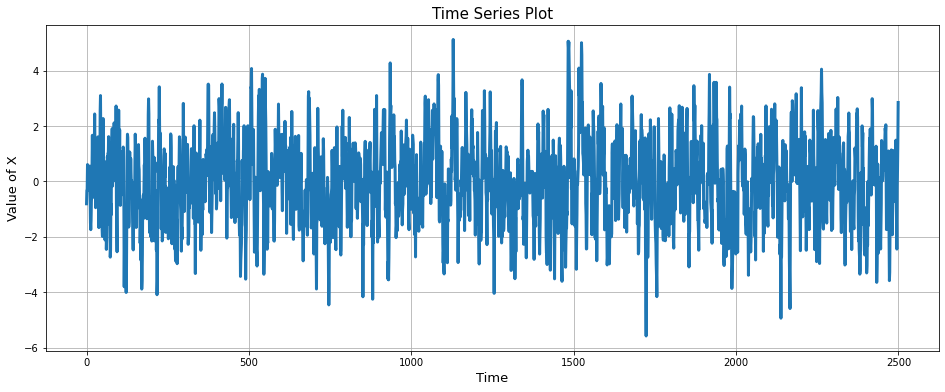

In [ ]:
plot_series(X)

### ACF and PACF plots


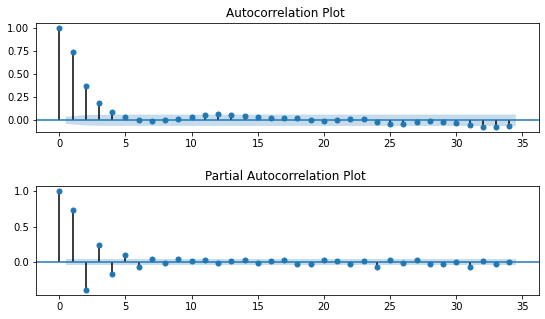

In [ ]:
def plot_graphs(ar_params=None, ma_params=None, X=None):
    """ Plots ACF and PACF graphs
        
        It takes in the time series data and plots the ACF and PACF graphs for 
        the series. When the time series is not provided but it generates the 
        time-series using the params and generates data. Then, the ACF and PACF 
        graphs are plotted for the generated samples.

    Args:
        ar_params (np.array): AR parameters - (phi1, phi2, ...)
        ma_params (np.array): MA parameters - (theta1, theta2, ...)
        X (np.array): Time-series data 

    """
    
    title = 'Autocorrelation Plot '
    
    if X is None:
        ar = np.r_[1, -ar_params]
        ma = np.r_[1, ma_params] 
        arma_process = ArmaProcess(ar=ar, ma=ma) 
        X = arma_process.generate_sample(nsample=10000) 
        
        title += ' for ARMA model : AR={} MA={}'.format(str(ar_params), str(ma_params)) 
        
    fig = plt.figure(figsize=(9, 5))
    fig.subplots_adjust(hspace=0.5)

    # ACF plot
    ax1 = fig.add_subplot(211)
    sm.graphics.tsa.plot_acf(X, title=title, ax=ax1)

    # PACF plot
    ax2 = fig.add_subplot(212)
    sm.graphics.tsa.plot_pacf(X, title='Partial ' + title, ax=ax2)
    
    plt.show()

plot_graphs(X=X)

From the above figures for ACF and PACF plots for the ARMA(1, 1) process, we can realize that both PACF and ACF values tail off longer than the orders for AR and MA part. The ACF values are significantly large up to lag 4, whereas the PACF values are significantly large up to lag 6. Thus, as in only AR(p) model, the PACF values do not cut off after lag p, and as in only MA(q) model, the ACF values do not cut off after lag q. **It looks like we cannot infer the AR and MA parts' orders exactly from the graphs. Nevertheless, we can estimate the upper limit for the orders, and we can search for the best model in the range between 0 to the upper limits.**


## Relation between order, ACF and PACF plots for ARMA model

Let's explore with two models with order (2, 2) and (3, 3).

$X_t = 0.3 X_{t-1} + 0.2 X_{t-2} + Z_t + 0.6 Z_{t-1} + 0.3 Z_{t-2}$

$X_t = 0.3 X_{t-1} + 0.2 X_{t-2} + 0.1 X_{t-3} + Z_t + 0.6 Z_{t-1} + 0.3 Z_{t-2} + 0.2 Z_{t-3}$


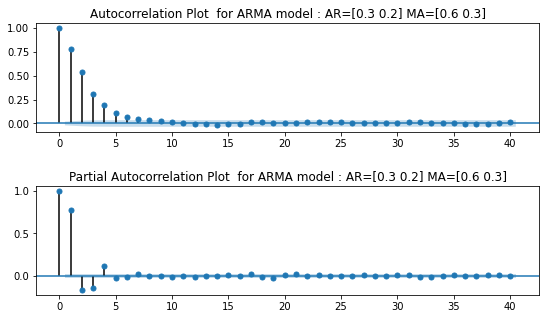

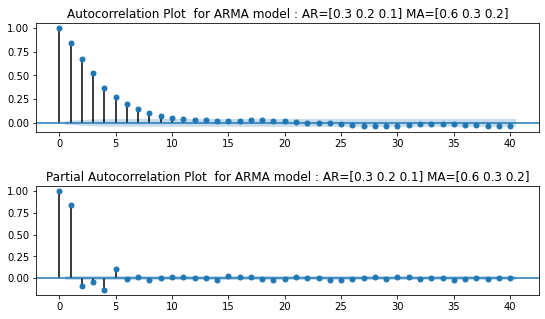

In [ ]:
# setting parameters
arma_params1 = np.array([0.3, 0.2]), np.array([0.6, 0.3]) 
arma_params2 = np.array([0.3, 0.2, 0.1]), np.array([0.6, 0.3, 0.2]) 

# ACF and PACF plots
plot_graphs(*arma_params1)
plot_graphs(*arma_params2)

### Observation

From the above experimentation, we can conclude that the lags at which the ACF and PACF values cut off are a bit bigger than the MA and AR part orders. 




## Fitting ARMA(p, q) model

Let's use a synthetic dataset. Let's generate the dataset using the following ARMA(2, 2) process.

>$X_t = 0.3 X_{t-1} + 0.1 X_t{t} + Z_{t} + 0.5 Z_{t-1} + 0.3 Z_t{t}$


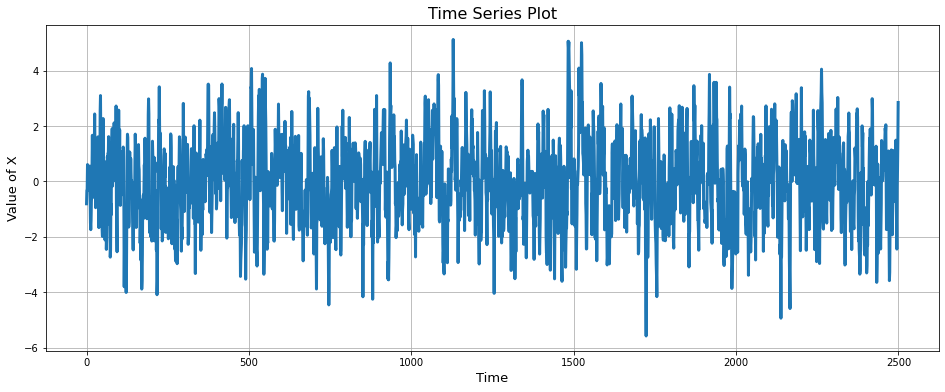

In [ ]:
# Synthetic data generation
ar_params = np.array([0.3, 0.1]) 
ma_params = np.array([0.5, 0.3]) 

ar = np.r_[1, -ar_params]
ma = np.r_[1, ma_params] 

ar_process = ArmaProcess(ar, ma) 

np.random.seed(1000)
X = ar_process.generate_sample(nsample=2500)

plot_series(X)

Now, we have generated the synthetic dataset, $X$. We know that the underlying data generation process is an ARMA(2, 2). However, for real-world datasets, we don't see the data generation process in advance. Thus, we follow the following steps to find a good ARMA model to fit the data. 

\\

**Steps:**

1. **Stationarity Check**: The ARMA model cannot handle data with trends and seasonality. The data must be stationary to fit an ARMA model. Thus we have to check whether the data on hand is stationary or not before. If the data is stationary, we proceed to 2; else, we need to look for other models. 

2. **Estimate Orders**: If the data is stationary and one of the graphs seems to tail off while the other one cuts off, we can fit an AR or MA model, as we discussed in previous chapters. If the data is stationary and both of the graphs tail off, we can estimate the upper limits for the orders for possible ARMA model using ACF and PACF graphs.

    -  $\hat{p}$ - lag up to which the PACF values are significant.
    -  $\hat{q}$ - lag up to which the ACF values are significant.

$$\begin{array} 
\ &  & \textbf{AR}(p) &  & \textbf{MA}(q) &  & \textbf{ARMA}(p, q) 
\\
\textbf{ACF} & | & \text{tails off at lags}\ k  & | & \text{cuts off after lag}\ q & | & \text{tails off at lags}\ k 
\\
\textbf{PACF} & | & \text{cuts off after lag}\ p & | & \text{tails off at lags}\ k & | & \text{tails off at lags}\ k 
\end{array}$$


3. **Fit and Select Model**: Fit models for $p \in [0, \hat{p}]$ and $q \in [0, \hat{q}]$ and obtain the best model by brute force search based on the evaluation criterion.


### Stationarity Check

We'll use the Augmented Dicky-Fuller (ADF) test with a threshold of $0.05$ to check the stationarity of the data. You can learn more about ADF test in our reading material **Time Series Data Preprocessing** in the topic **Stationarity Check- Augmented Dicky-Fuller (ADF) Test**. We calculate the p_value of the data using `adfuller` function in `statsmodels`. 


In [ ]:
# ADF test
p_threshold = 0.05
p_val = stattools.adfuller(X)[1]

print(p_val)
print(p_val < p_threshold)

2.0683524071070683e-30
True


Since the p_value is smaller than the threshold, we assume the data is stationary, and we proceed to select the orders of the model; else, we should have stopped and searched for other complicated models.  


### Estimate Orders

We'll plot the ACF and PACF graphs for the stationary data $(X)$ and observe the patterns of the values and use this observation to infer the rough orders for the AR and the MA parts.



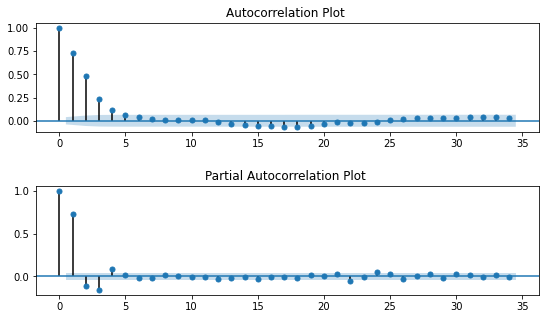

In [ ]:
plot_graphs(X=X)

Observing the ACF plot, the ACF values appear to cut off after lag 5. So we set $\hat{q}$ to 5. Similarly, from the PACF plot, the PACF values appear cut off after lag 4, so we set $\hat{p}$ to 4.


In [ ]:
p_ = 4
q_ = 5

### Fit and Select Model

We'll use the Bayesian Information Criterion (BIC) as the evaluation metric. You can learn more about BIC and performance evaluation in our reading material named **Performance Evaluation and Residual Diagnostics**. We can make brute force search over the ranges of orders to obtain the model with the minimum BIC value. For this, we can use `optimize.brute` from `scipy`. Know that it will take a while for the brute force search. 


In [ ]:
# minimization function
def f(order, X):
    """ Minimization function
        It generates a ARMA model with provided orders and fits on the time series.
        
    Args:
        order ((int, int, int, int)): Tuple of (p, q, P, Q)
        X (np.array): Time-series data
        
    Returns:
        (float or np.inf): BIC score for the model and np.inf in case of any exception
        
    """
    
    try:
        model = sm.tsa.ARMA(X, order=order).fit()
    except ValueError:
        return np.inf
    return model.bic

# brute force search for the order for minimum bic
ar_orders = slice(0, p_, 1)
ma_orders = slice(0, q_, 1)
order_ranges = (ar_orders, ma_orders)

min_order = optimize.brute(f, order_ranges, args=(X,), finish=None)
min_order = min_order.astype(int)
min_order

array([1, 2])

In [ ]:
p, q = min_order

### Predictions

Let's use the model with the lowest BIC and observe the forecast made by the model against the actual data. We predict the last 20 observed time series data and future 12 values using `plot_predict` function of the fitted model.


[]

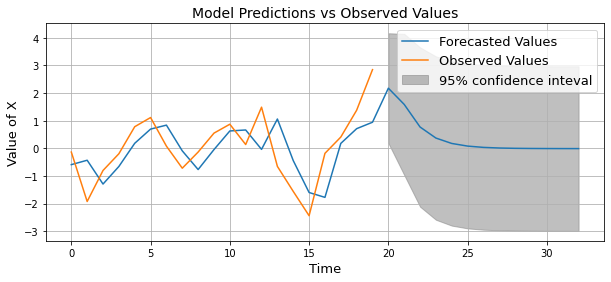

In [ ]:
model = sm.tsa.ARMA(X, order=(p, q)).fit()

ax = plt.figure(figsize=(10, 4)).add_subplot(111)
model.plot_predict(
    len(X) - 20, len(X) + 12, 
    dynamic=False, ax=ax, plot_insample=True
)

plt.title('Model Predictions vs Observed Values', fontsize=14)
plt.legend(['Forecasted Values', 'Observed Values', '95% confidence inteval'], fontsize=13)
plt.xlabel('Time', fontsize=13)
plt.ylabel('Value of X', fontsize=13)

plt.grid()
plt.plot()

The last 20 observed values of the time series are shown by orange curve. The blue curve shows the values forecasted by the model. The dark gray region shows the 95% confidence interval for the forecasted values.


## Key Takeaways

1. In the ARMA(p, q) model, $X_t$ is taken as the linear combination of the $p$ past values for $X$ ($X_{t-1}, X_{t-2}, X_{t-3}, . . . ,X_{t-p}$), $q$ past noise values ($Z_{t-1}, Z_{t-2}, Z_{t-3}, . . . ,Z_{t-q}$) and some random noise at time t ($Z_t$).

2. ARMA models can handle stationary datasets only. 

3. For ARMA(p, q) models, both ACF and PACF values tail off.  We can use ACF and PACF plots to estimate the ranges of the MA and AR parts' orders.

4. Different models with orders in the estimated ranges are fitted by brute force, and the model with the best evaluation metric is chosen. 

